## **Notebook 3 - Model Insights and Feature Analysis**

In this notebook, we analyze the performance of the trained machine learning model and extract meaningful insights.

#### Objectives:
- Understand important features influencing predictions
- Analyze model errors and misclassifications
- Interpret model behavior
- Generate business insights from predictions

This step enhances model interpretability and provides actionable insights.

#### **Import Libraries**

In [61]:
import pandas as pd
import numpy as np
import logging
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

#### **Logger Configuration**

This project uses Python logging instead of print statements.

Why?
- Debugging large datasets
- Tracking preprocessing steps
- Production ML pipelines
- Helps identify where a failure occurred

All activities will be recorded inside:
`model_insights_feature_analysis.log`

In [62]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
LOG_DIR = PROJECT_ROOT / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

LOG_FILE = LOG_DIR / "model_insights_feature_analysis.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE, mode="a", encoding="utf-8")
    ],
    force=True
)

logger = logging.getLogger(__name__)

logger.info("==== MODEL INSIGHTS & FEATURE ANALYSIS PIPELINE STARTED ====")
print(f"Logging to: {LOG_FILE}")

Logging to: E:\DData\Projects\DSC\NextHikes\Python\disaster-tweet-classification-nlp-pro-7\logs\model_insights_feature_analysis.log


#### **Load Data and Trained Model**

In [63]:
df = pd.read_csv("../data/complete_dataset_prepared.csv")
test_df = pd.read_csv("../data/test_dataset_prepared.csv")

tfidf = pickle.load(open("../models/tfidf.pkl", "rb"))
model = pickle.load(open("../models/best_model.pkl", "rb"))

#### Prepare Data for Prediction

In [64]:
logger.info("Preparing data for model insights and feature analysis...")
X = df["clean_text"]
y = df["target"]

X_tfidf = tfidf.transform(X)
y_pred = model.predict(X_tfidf)

logger.info("Preparation of data for model insights and feature analysis completed.")

---
### **CORE INSIGHT SECTION**

#### **Confusion Matrix**

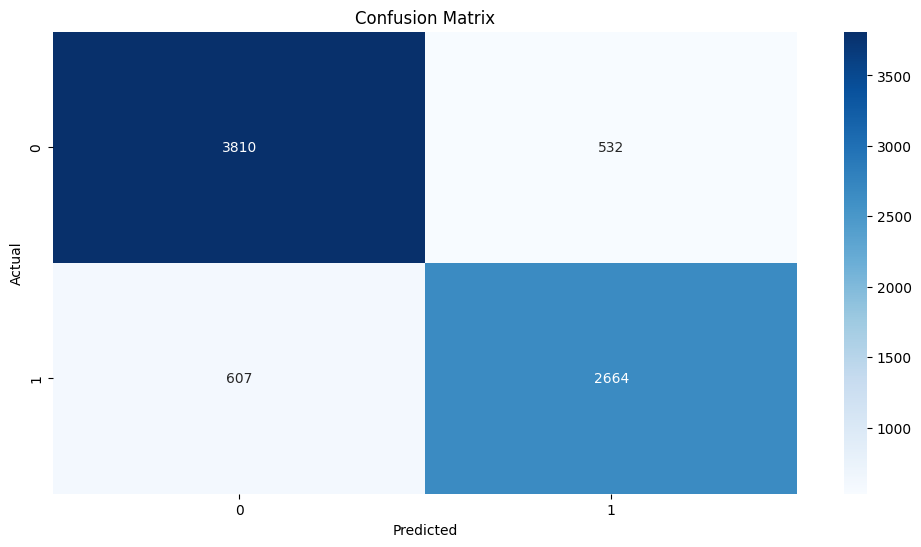

In [65]:
logger.info("Confusion Matrix:\n%s", confusion_matrix(y, y_pred))
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
logger.info("Confusion matrix heatmap displayed.")

#### **Classification Report**

In [66]:
logger.info("Classification Report:\n%s", classification_report(y, y_pred))
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4342
           1       0.83      0.81      0.82      3271

    accuracy                           0.85      7613
   macro avg       0.85      0.85      0.85      7613
weighted avg       0.85      0.85      0.85      7613



---

### **ROC Curve**

The ROC curve shows the trade-off between True Positive Rate (Recall) and False Positive Rate.

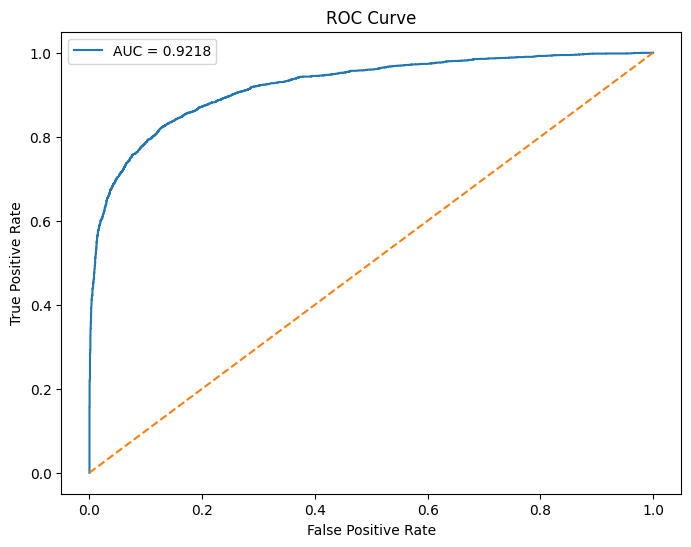

In [67]:
logger.info("ROC Curve and AUC analysis...")
# Only works if model supports predict_proba
if hasattr(model, "predict_proba"):
    y_probs = model.predict_proba(X_tfidf)[:, 1]

    fpr, tpr, _ = roc_curve(y, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f"AUC = {round(roc_auc,4)}")
    plt.plot([0,1], [0,1], linestyle="--")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
logger.info("ROC curve displayed with AUC: %.4f", roc_auc)

---

### **Precision-Recall Curve**

This curve is especially useful for imbalanced classification problems.

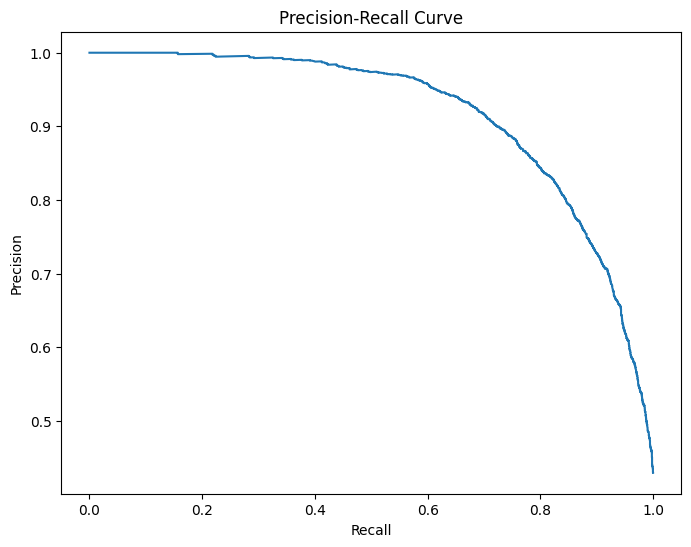

In [68]:
logger.info("Precision-Recall Curve analysis started...")

if hasattr(model, "predict_proba"):
    precision, recall, _ = precision_recall_curve(y, y_probs)

    plt.figure(figsize=(8,6))
    plt.plot(recall, precision)
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()
logger.info("Precision-Recall curve displayed.")

#### **Top Important Words (Feature Importance)**

In [69]:
logger.info("Extracting feature importance from the model...")
feature_names = tfidf.get_feature_names_out()

if hasattr(model, "coef_"):
    coefs = model.coef_[0]
    
    top_positive = np.argsort(coefs)[-20:]
    top_negative = np.argsort(coefs)[:20]
    
    print("Top Disaster Words:")
    print([feature_names[i] for i in top_positive])
    
    print("\nTop Non-Disaster Words:")
    print([feature_names[i] for i in top_negative])
    logger.info("Top Disaster Words: %s", [feature_names[i] for i in top_positive])
    logger.info("Top Non-Disaster Words: %s", [feature_names[i] for i in top_negative])

Top Disaster Words:
['mass', 'tornado', 'buildings', 'near', 'police', 'bombing', 'earthquake', 'killed', 'massacre', 'accident', 'suicide', 'floods', 'fire', 'train', 'storm', 'wildfire', 'california', 'fires', 'in', 'hiroshima']

Top Non-Disaster Words:
['you', 'my', 'new', 'im', 'love', 'full', 'or', 'harm', 'body', 'hes', 'bloody', 'upheaval', 'wrecked', 'nowplaying', 'show', 'bags', 'let', 'crushed', 'demolish', 'all']


#### **Misclassified Tweet Analysis**

This step identifies tweets for which the predicted label does not match the actual target label.

- a new column `predicted` stores the model’s predicted class
- misclassified records are filtered by comparing `target` and `predicted`
- the output displays the original text, cleaned text, actual label, and predicted label

This helps examine model errors and understand the types of tweets the classifier struggles to predict correctly.


In [70]:
logger.info("Missclassified Tweet Analysis - Displaying first 10 misclassified examples...")
df["predicted"] = y_pred
misclassified = df[df["target"] != df["predicted"]]
logger.info(misclassified[["text", "clean_text", "target", "predicted"]].head(10))
misclassified[["text", "clean_text", "target", "predicted"]].head(10)

,text,clean_text,target,predicted
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...,1,0
11,Haha South Tampa is getting flooded hah- WAIT ...,haha south tampa is getting flooded hah wait a...,1,0
12,#raining #flooding #Florida #TampaBay #Tampa 1...,raining flooding florida tampabay tampa or day...,1,0
26,Was in NYC last week!,was in nyc last week,0,1
35,On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,on plus side look at the sky last night it was...,0,1
43,SOOOO PUMPED FOR ABLAZE ???? @southridgelife,soooo pumped for ablaze,0,1
47,Building the perfect tracklist to life leave t...,building the perfect tracklist to life leave t...,0,1
52,SANTA CRUZ ÛÓ Head of the St Elizabeth Police...,santa cruz ûó head of the st elizabeth police...,0,1
60,Revel in yours wmv videos by means of mac fare...,revel in yours wmv videos by means of mac fare...,0,1
61,Progressive greetings!\n\nIn about a month stu...,progressive greetings in about a month student...,0,1


#### **Error Pattern Analysis**
#### Word Count Distribution in Misclassified Tweets

This section examines the word count of tweets that were incorrectly classified by the model.

- the number of words is calculated from the `clean_text` column
- a histogram is used to visualize the distribution of word counts
- this helps identify whether misclassified tweets tend to be shorter or longer in length

The analysis provides insight into whether tweet length may influence prediction errors.


C:\Users\Aishwarya Kr Singh\AppData\Local\Temp\ipykernel_17268\2816696722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  misclassified["word_count"] = misclassified["clean_text"].apply(lambda x: len(x.split()))


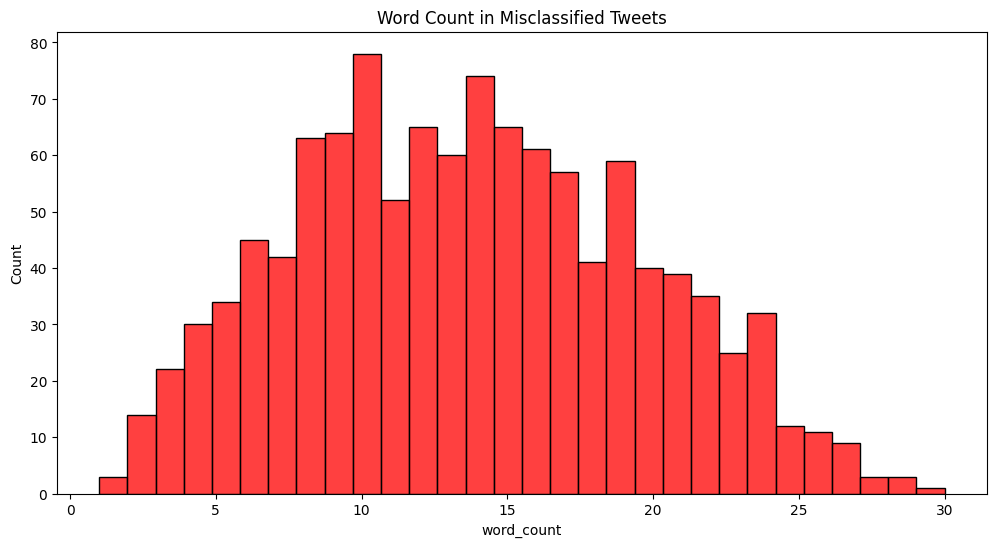

,id,keyword,location,text,clean_text,tokens,text_length_chars,word_count,has_hashtag,has_mention,has_url,target,predicted
4,7,missing,missing,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...,"['just', 'got', 'sent', 'this', 'photo', 'from...",88,16,True,False,False,1,0
11,17,missing,missing,Haha South Tampa is getting flooded hah- WAIT ...,haha south tampa is getting flooded hah wait a...,"['haha', 'south', 'tampa', 'is', 'getting', 'f...",129,27,True,False,False,1,0
12,18,missing,missing,#raining #flooding #Florida #TampaBay #Tampa 1...,raining flooding florida tampabay tampa or day...,"['raining', 'flooding', 'florida', 'tampabay',...",76,10,True,False,False,1,0
26,38,missing,missing,Was in NYC last week!,was in nyc last week,"['was', 'in', 'nyc', 'last', 'week']",21,5,False,False,False,0,1
35,53,ablaze,"London, UK",On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,on plus side look at the sky last night it was...,"['on', 'plus', 'side', 'look', 'at', 'the', 's...",76,12,False,False,True,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7501,10730,wreck,missing,@TitorTau The Loretta Lynch one was fuckin' HI...,the loretta lynch one was fuckin hilarious to ...,"['the', 'loretta', 'lynch', 'one', 'was', 'fuc...",138,21,False,True,False,0,1
7552,10795,wrecked,"Santa Cruz, CA",Israel wrecked my home. Now it wants my land. ...,israel wrecked my home now it wants my land,"['israel', 'wrecked', 'my', 'home', 'now', 'it...",70,9,False,False,True,1,0
7572,10823,wrecked,"Manhattan, NY",@Kirafrog @mount_wario Did you get wrecked again?,did you get wrecked again,"['did', 'you', 'get', 'wrecked', 'again']",49,5,False,True,False,1,0
7594,10849,missing,missing,A gas thing just exploded and I heard screams ...,a gas thing just exploded and i heard screams ...,"['a', 'gas', 'thing', 'just', 'exploded', 'and...",91,17,False,False,False,1,0


In [71]:
logger.info("Analyzing word count in misclassified tweets...")
misclassified["word_count"] = misclassified["clean_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.histplot(misclassified["word_count"], bins=30, color="red")
plt.title("Word Count in Misclassified Tweets")
plt.show()
logger.info("Word count distribution for misclassified tweets displayed.")
misclassified

---
### **BUSINESS INSIGHTS**
### Key Insights

#### Observations:

- Disaster tweets often contain keywords such as "fire", "flood", "accident", "evacuation"
- Non-disaster tweets often include metaphorical usage of disaster-related words
- Misclassifications occur in:
  - Short ambiguous tweets
  - Tweets with sarcasm or informal language

#### Implications:

- Context understanding is critical in NLP problems
- Simple models may struggle with semantic meaning
- More advanced models (LSTM/BERT) can improve results

---
### **SAVE ANALYSIS**

In [72]:
logger.info("Saving misclassified tweets to CSV file...")
misclassified.to_csv("../data/misclassified_tweets.csv", index=False)
logger.info("Misclassified tweets saved to `../data/misclassified_tweets.csv` file.")
logger.info("==== MODEL INSIGHTS & FEATURE ANALYSIS PIPELINE COMPLETED ====")

---

### **Summary**

In this notebook, we analyzed the trained machine learning model to understand its behavior and limitations.

#### Key Steps:

- Evaluated model predictions on the full dataset
- Generated confusion matrix and classification report
- Identified important features influencing predictions
- Analyzed misclassified examples
- Extracted meaningful insights from the data

#### Key Findings:

- The model performs well on clear disaster-related tweets
- Misclassification occurs in ambiguous and context-dependent cases
- Feature importance highlights key disaster-related terms

---

#### Conclusion

This analysis provides deeper understanding of model performance and highlights areas for improvement, such as handling contextual ambiguity.

---

#### Next Steps

- Implement Deep Learning models (LSTM)
- Explore contextual embeddings (BERT)
- Improve performance on ambiguous cases